<a href="https://colab.research.google.com/github/OlaniyiSegunIsrael/Assignment-14-SO/blob/main/Assignment%2014.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment: Ethical AI Analysis and Explainability

##Assignment Link
- Google Colab: https://colab.research.google.com/drive/1-yQl5sx-EqmFFBmQ1w0-AkOROYnqPGaW?usp=sharing

- Git Hub: https://github.com/OlaniyiSegunIsrael/Assignment-14-SO

In [16]:
!apt-get install -y git
!git config --global user.email "segun.olaniyi@students.williscollege.com"
!git config --global user.name "OlaniyiSegunIsrael"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [17]:
!git clone https://github.com/OlaniyiSegunIsrael/Assignment-14-SO.git
%cd Assignment-14-SO
!ls

Cloning into 'Assignment-14-SO'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/Assignment-14-SO
README.md


In [18]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [2]:
# STEP 1: IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, true_positive_rate

import shap
from lime.lime_tabular import LimeTabularExplainer

In [3]:
# STEP 2: LOAD DATASET

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Create a simple "sensitive feature"
# Example: age-like proxy using mean radius (just for demo)
sensitive_feature = pd.cut(X["mean radius"], bins=2, labels=["Group_A", "Group_B"])


In [4]:
# STEP 3: TRAIN TEST SPLIT

X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X, y, sensitive_feature, test_size=0.3, random_state=42)

In [5]:
# STEP 4: TRAIN MODEL

model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)


# STEP 5: MODEL EVALUATION

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9707602339181286

Confusion Matrix:
 [[ 60   3]
 [  2 106]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96        63
           1       0.97      0.98      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [6]:
# STEP 6: FAIRNESS ANALYSIS

metrics = {
    "accuracy": accuracy_score,
    "selection_rate": selection_rate,
    "false_positive_rate": false_positive_rate,
    "true_positive_rate": true_positive_rate}

metric_frame = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=s_test)

print("\nFairness Metrics by Group:\n")
print(metric_frame.by_group)


Fairness Metrics by Group:

             accuracy  selection_rate  false_positive_rate  true_positive_rate
mean radius                                                                   
Group_A      0.964286        0.778571              0.09375            0.981481
Group_B      1.000000        0.000000              0.00000            0.000000


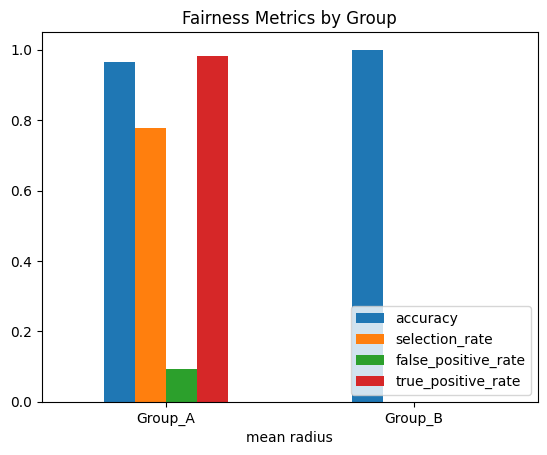

In [10]:
# STEP 7: VISUALIZATION

metric_frame.by_group.plot(kind="bar")
plt.title("Fairness Metrics by Group")
plt.xticks(rotation=0)
legend = plt.legend(loc="lower right")
plt.show()


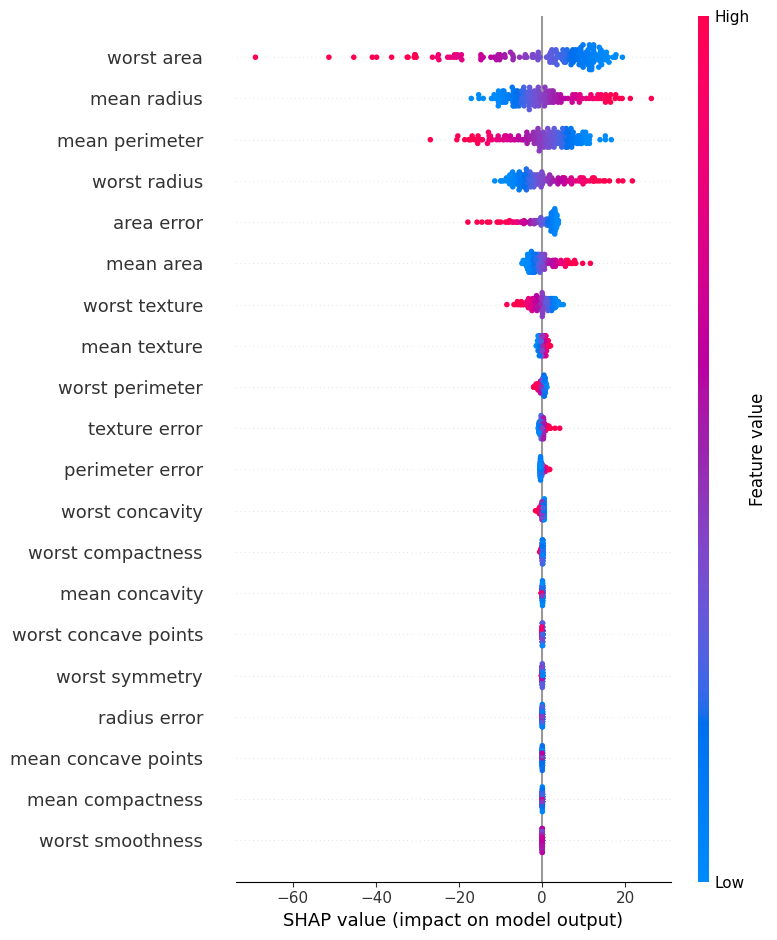

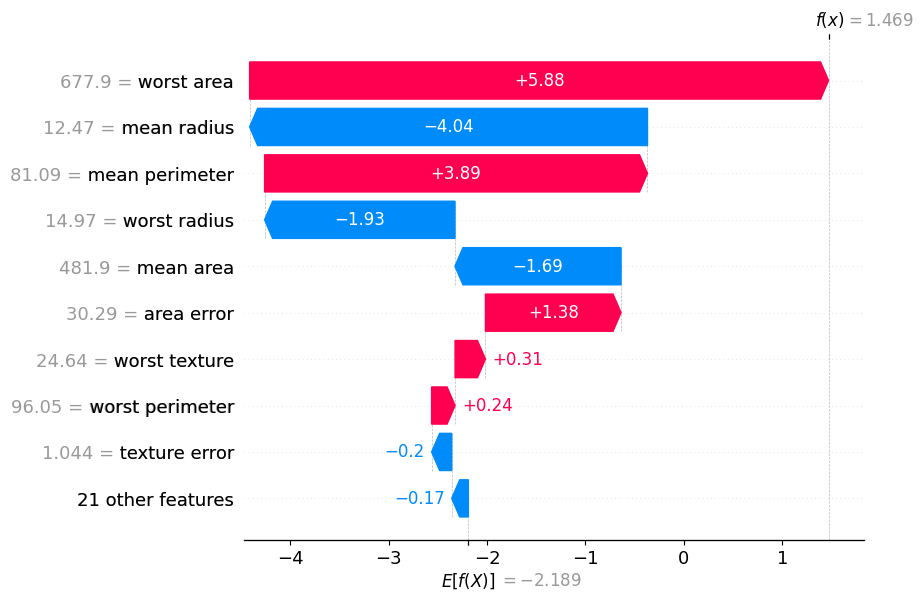

In [12]:
# STEP 8: SHAP EXPLAINABILITY

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Global explanation
shap.summary_plot(shap_values, X_test)

print()

# Local explanation (single prediction)
shap.plots.waterfall(shap_values[0])

In [15]:
# STEP 9: LIME EXPLAINABILITY

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns,
    class_names=["Malignant", "Benign"],
    mode="classification")

# Explain one instance
exp = lime_explainer.explain_instance(
    X_test.iloc[0].values,
    model.predict_proba)

print("\nLIME Explanation:")
exp.show_in_notebook(show_table=True)


LIME Explanation:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
